# Plotting Vector Data

This notebook demonstrates how to plot `.gpml` data using gplately. In geology and plate tectonic modeling, GPML (GPlates Markup Language) files are a standard format for storing and exchanging plate reconstruction data. They contain geospatial vector features—such as coastlines, plate boundaries, or topologies. These come along with associated plate IDs and geological metadata that allow these features to be reconstructed through time using a rotation model.

### Setup

Let’s start by importing the required packages.

In [6]:
# Ensure you have the required packages installed:
# Run `pip install gplately pygplates cartopy geopandas matplotlib pandas numpy` if not already installed.
import gplately
from plate_model_manager import PlateModelManager
import pygplates
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

Now, let's use gplately's `PlateModelManager` to create a plate reconstruction model based on the Müller et al. (2019) global plate model, [“A Global Plate Model Including Lithospheric Deformation Along Major Rifts and Orogens Since the Triassic”](https://www.earthbyte.org/muller-et-al-2019-deforming-plate-reconstruction-and-seafloor-age-grids-tectonics/).

> `NOTE:` You can also load a plate model through local files on your system!

We then extract individual layers from the model:

- Coastlines: for reconstructing ancient shorelines.

- ContinentalPolygons: for plotting continental outlines.

- COBs (Continent-Ocean Boundaries): useful for defining the transition between land and oceanic crust.

Finally, we create a `PlotTopologies object (gplot)`, which simplifies visualizing reconstructed features like plate boundaries, continents, and COBs at any geological time.

In [7]:
pm_manager = PlateModelManager()

# Load the Muller 2019 plate model 
muller2019_model = pm_manager.get_model("Muller2019", data_dir="../../data/plate-model-repo")

# This object will allow us to reconstruct the plate boundaries at different times
model = gplately.PlateReconstruction(
    muller2019_model.get_rotation_model(),
    muller2019_model.get_topologies(),
    muller2019_model.get_static_polygons()
)

# Coastlines, Continental polygons and COBs
coastlines = muller2019_model.get_layer('Coastlines')
continents = muller2019_model.get_layer('ContinentalPolygons')
COBs = muller2019_model.get_layer('COBs')
rotation_model = muller2019_model.get_rotation_model()
static_polygons_filename = muller2019_model.get_static_polygons()

# Create PlotTopologies object
gplot = gplately.PlotTopologies(model, coastlines=coastlines, continents=continents, COBs=COBs)

time_ma = 100  # Ma (Million years ago)

### Importing GPML Data

We’re using the file `Whittaker_etal_2015_LIPs.gpmlz`, which contains a global compilation of Large Igneous Provinces (LIPs) interpreted to be the surface expressions of mantle plume activity [(Whittaker et al., 2015)](https://www.earthbyte.org/long-term-interaction-between-mid-ocean-ridges-and-mantle-plumes/). These features represent major volcanic events that have played a key role in shaping Earth’s lithosphere and influencing plate tectonic evolution over geological time.

First, we define the path to the GPML file. Then the dataset is read into a `FeatureCollection`, allowing GPlately to access and manipulate each LIP polygon as a geological feature.

In [8]:
# --- Path to your GPML topology file ---
gpml_path = "../../data/GeoData/FeatureCollections/IgneousProvinces/Whittaker_2015/Whittaker_etal_2015_LIPs.gpmlz"

# --- Load the GPML file as a FeatureCollection ---
topology_features = pygplates.FeatureCollection(gpml_path)

### Plotting & Reconstructing

In this section, we use `Cartopy` to visualize our geological data on a global map, together with the [PlotTopologies object](https://gplates.github.io/gplately/latest/sphinx/html/generated/gplately.PlotTopologies.html) from gplately for plotting coastlines and geological features.

We’ll create two separate plots:

- One showing the present-day locations of Large Igneous Provinces (LIPs), and

- Another showing how these features looked when reconstructed back in time using a plate motion model.

Both plots help us explore how major volcanic provinces are distributed across the Earth’s surface.

#### Plot 1 – Present Day (0 Ma)

This plot shows the present-day distribution of Large Igneous Provinces displayed in dark green, over modern coastlines shown in black. It provides a snapshot of where these massive volcanic regions exist on Earth today.

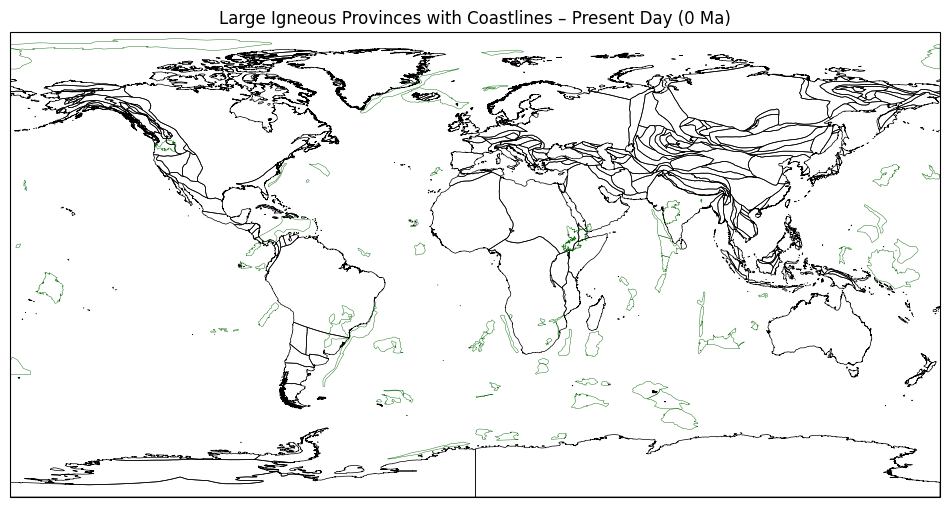

In [9]:
# --- PLOT 1: Present Day (0 Ma) ---
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

gplot.time = 0

gplot.plot_coastlines(ax, color='black', linewidth=0.5)

# Plot present-day coastlines using PlotTopologies object
gplot.plot_feature(
    ax,
    topology_features,
    color='darkgreen',
    linewidth=0.3
)

plt.title('Large Igneous Provinces with Coastlines – Present Day (0 Ma)')
plt.show()

#### Plot 2 – Reconstructed to 100 Ma

In this plot, we reconstruct the Large Igneous Provinces (LIPs) back to 100 million years ago using a plate reconstruction model. The `model.reconstruct()` function moves each geological feature to its estimated position at that time, based on known plate motions.

- The black lines show reconstructed coastlines, representing where continents and oceans were located at 100 Ma.

- The dark green polygons show the reconstructed positions of LIPs, illustrating how these volcanic provinces were distributed across ancient plate configurations.

This helps visualize how Earth’s surface and volcanic activity have changed over geological time!

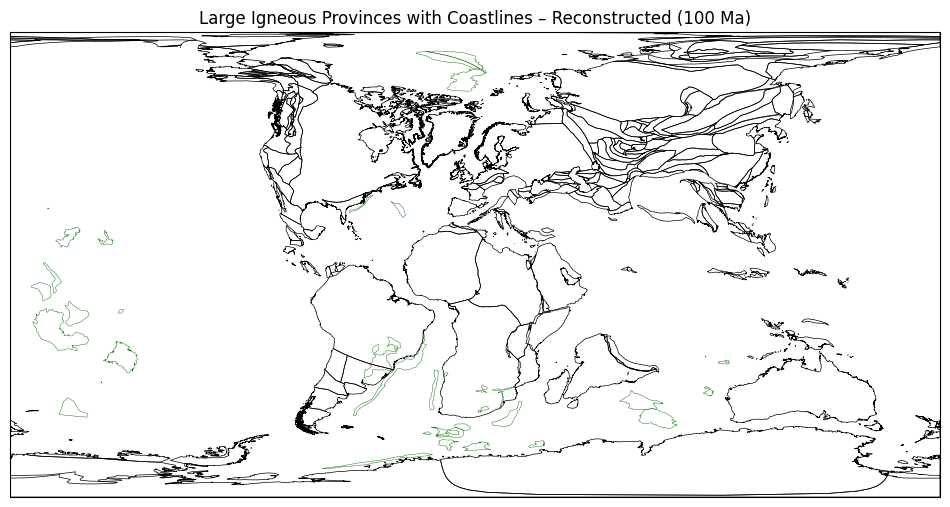

In [10]:
# --- PLOT 2: Reconstructed to 100 Ma ---
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

gplot.time = time_ma    # Set time to 100 Ma

# Plot reconstructed coastlines
gplot.plot_coastlines(ax, color='black', linewidth=0.5)

# Reconstruct topology features to 100 Ma
reconstructed_topology = model.reconstruct(
    topology_features,
    to_time=time_ma,   # Time = 100 Ma (from setup above)
    anchor_plate_id=model.anchor_plate_id
)

# Plot reconstructed topology
gplot.plot_feature(
    ax,
    reconstructed_topology,
    color='darkgreen',
    linewidth=0.3
)

plt.title(f'Large Igneous Provinces with Coastlines – Reconstructed ({time_ma} Ma)')
plt.show()